### File Sampling & Loading

In [11]:
import pandas as pd
import glob

In [31]:
# Load in the Russian tweets and sample
rtweets = pd.read_csv('ira_tweets_csv_hashed.csv')
sampled_rtweets = rtweets.sample(n=len(rtweets)*.10)
sampled_rtweets.shape
rtweets.to_csv('sampled_rtweets.csv', index=False)

In [24]:
# Load the sampled Russian Tweets
rtweets = pd.read_csv('sampled_rtweets.csv')
rtweets.shape

In [ ]:
# Load in control group tweets

#Function from: https://stackoverflow.com/questions/20906474/import-multiple-csv-files-into-pandas-and-concatenate-into-one-dataframe
path =r'/Users/ScottHenry/Projects/SI670/project/data/download' 
allFiles = glob.glob(path + "/*.tsv")

list_ = []

# Multiple tsv files
for file_ in allFiles:
    df = pd.read_csv(file_,index_col=None, header=0, sep='\t')
    list_.append(df)

ntweets = pd.concat(list_, axis = 0, ignore_index = True)

ntweets.to_csv('sampled_ntweets.csv', index=False)

In [ ]:
# Load the control group tweets
ntweets = pd.read_csv('sampled_ntweets.csv')
ntweets.shape

### Data Processing

In [ ]:
# Column selection & labeling of the normal tweets
ntweets = ntweets[['created_at','lang','text','retweeted']]
ntweets.columns = ['time','lang','text','retweeted']
ntweets['label'] = 0

In [48]:
# Column selection & labeling of the Russian tweets
rtweets = rtweets[['tweet_time','tweet_language','tweet_text','is_retweet']]
rtweets.columns = ['time','lang','text','retweeted']
rtweets['label'] = 1

In [51]:
# Merge the normal and Russian tweets into one group
tweets = pd.concat([rtweets,ntweets])

#Fix DateTime Formatting
tweets_df.dropna(inplace=True)
tweets_df['time'] = pd.to_datetime(tweets_df['time'])

tweets.to_csv('tweets.csv', index=False)

### Input

In [3]:
import pandas as pd

In [2]:
# Load in the combinded dataframe
tweets_df = pd.read_csv('tweets.csv')

/home/ubuntu/anaconda3/envs/tensorflow_p36/lib/python3.6/site-packages/IPython/core/interactiveshell.py:2785: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [3]:
# Load in the combinded dataframe
tweets_df = pd.read_csv('tweets_clean.csv')

### Text Cleaning

In [4]:
import re
import os
import nltk
from nltk.corpus import stopwords
#nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

In [5]:
def cleantext(txt):
    txt = txt.replace(os.linesep, "")
    txt = re.sub("\d+", "", txt)
    txt = txt.lower()
    txt = re.sub(r'[^\w\s]', '', txt)
    txt = ' '.join([word for word in txt.split() if word not in stop_words])
    return txt

In [ ]:
tweets_df.dropna(inplace=True)
tweets_df['time'] = pd.to_datetime(tweets_df['time'])
tweets_df['text'] = tweets_df.apply(lambda x: cleantext(x['text']), axis=1)

In [ ]:
tweets_df.to_csv('tweets_clean.csv', index=False)

### Tokenizing

In [4]:
from keras import preprocessing
from keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import pad_sequences
import numpy as np

In [5]:
tweets_df = pd.read_csv('tweets_clean.csv')

In [6]:
# Shuffle Tweets
tweets = tweets_df.sample(frac=1,random_state=145 )

In [7]:
# Sample for testing
tweets = tweets.sample(frac=.025, random_state=145)

In [8]:
# Convert to a string & list
tweets['text'] = tweets['text'].astype(str)
texts = tweets['text'].tolist()
labels = np.array(tweets['label'].tolist())
times = np.array(tweets['time'].tolist(),dtype=np.datetime64).reshape(-1,1)

In [9]:
tweets.groupby('label').count()

,time,lang,text,retweeted
label,,,,
0,22415,22415,22415,22415
1,6545,6545,6545,6545


In [10]:
# Tokenize
max_len = 100
max_words = 10000

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

word_index = tokenizer.word_index

In [11]:
# Create tensors of the same size
data = pad_sequences(sequences, maxlen=max_len)

In [12]:
# Train/test split for Model 2
text_train, text_test, time_train, time_test, labels_train, labels_test = train_test_split(data, times,labels, random_state=5)
#time_train = time_train.reshape(-1,1)

In [13]:
# Train/test split for Model 0 & 1
X_train, X_test, y_train, y_test = train_test_split(data, labels, random_state=5)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [14]:
len(X_train)

21720

### Dummy Classifier

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

In [20]:
clf = DummyClassifier(strategy="most_frequent")
clf.fit(X_train,y_train)
clf.score(X_test, y_test)

0.7765193370165746

### Modeling

In [84]:
from keras.models import Sequential, Model
from keras.layers import Flatten, Dense, LSTM, Bidirectional,Input, Embedding
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import keras as keras
import seaborn as sns

In [26]:
# Assemble model paramters
embedding_dim = 150
input_length = len(X_train[100])

### Model 0 (Basic LSTM)

In [27]:
# Create layers for model #0
model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=input_length))
model.add(LSTM(32))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 100, 150)          1500000   
_________________________________________________________________
lstm_1 (LSTM)                (None, 32)                23424     
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 33        
Total params: 1,523,457
Trainable params: 1,523,457
Non-trainable params: 0
_________________________________________________________________


In [28]:
# Run the model
results = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.7)

# Save model
model.save('my_model_0.h5')

Train on 6516 samples, validate on 15204 samples
Epoch 1/5
6516/6516 [==============================] - 74s 11ms/step - loss: 0.3957 - acc: 0.8465 - val_loss: 0.3024 - val_acc: 0.8900
Epoch 2/5
6516/6516 [==============================] - 71s 11ms/step - loss: 0.2391 - acc: 0.9133 - val_loss: 0.2903 - val_acc: 0.8863
Epoch 3/5
6516/6516 [==============================] - 70s 11ms/step - loss: 0.1946 - acc: 0.9314 - val_loss: 0.3000 - val_acc: 0.8869
Epoch 4/5
6516/6516 [==============================] - 70s 11ms/step - loss: 0.1661 - acc: 0.9435 - val_loss: 0.3016 - val_acc: 0.8917
Epoch 5/5
6516/6516 [==============================] - 70s 11ms/step - loss: 0.1408 - acc: 0.9506 - val_loss: 0.3090 - val_acc: 0.8947


In [29]:
model_score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', model_score[0])
print('Test accuracy:', model_score[1])

Test loss: 0.29261815615451137
Test accuracy: 0.9008287292817679


In [30]:
# Classification Report for Y
y_pred_0 = model.predict_classes(X_test)
target_names = ['Normal', 'Propaganda']

print(classification_report(y_test, y_pred_0, target_names=target_names))

             precision    recall  f1-score   support

     Normal       0.91      0.97      0.94      5622
 Propaganda       0.86      0.67      0.75      1618

avg / total       0.90      0.90      0.90      7240



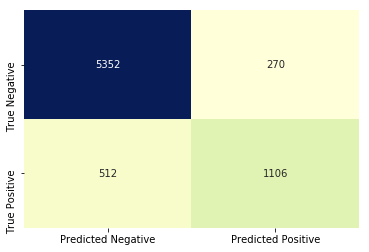

In [114]:
heatmap_0 = pd.DataFrame(confusion_matrix(y_test, y_pred))
heatmap_0.columns = ['Predicted Negative','Predicted Positive']
heatmap_0.index = ['True Negative', 'True Positive']
ax = sns.heatmap(heatmap_0, annot=True,fmt="d", cmap="YlGnBu",cbar=False)

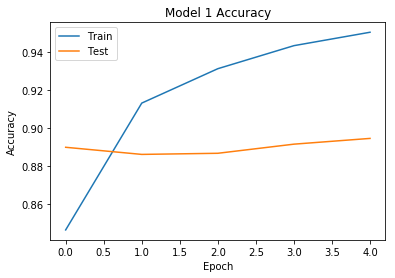

In [122]:
# Accuracy plot
plt.plot(results.history['acc'])
plt.plot(results.history['val_acc'])
plt.title('Model 1 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

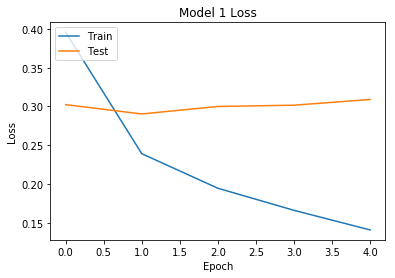

In [125]:
# Loss plot
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('Model 1 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Model 1 (Bidirectional LSTM)

In [32]:
# Create layers for model #1
model1 = Sequential()
model1.add(Embedding(max_words, embedding_dim, input_length=input_length))
model1.add(Bidirectional(LSTM(32)))
model1.add(Dense(1, activation = 'sigmoid'))
model1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model1.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 100, 150)          1500000   
_________________________________________________________________
bidirectional_1 (Bidirection (None, 64)                46848     
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 65        
Total params: 1,546,913
Trainable params: 1,546,913
Non-trainable params: 0
_________________________________________________________________


In [33]:
# Run the model
results1 = model1.fit(X_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.7)

# Save model
model.save('my_model_1.h5')

Train on 6516 samples, validate on 15204 samples
Epoch 1/5
6516/6516 [==============================] - 130s 20ms/step - loss: 0.3851 - acc: 0.8428 - val_loss: 0.3023 - val_acc: 0.8950
Epoch 2/5
6516/6516 [==============================] - 127s 20ms/step - loss: 0.2425 - acc: 0.9141 - val_loss: 0.2861 - val_acc: 0.8939
Epoch 3/5
6516/6516 [==============================] - 127s 19ms/step - loss: 0.1944 - acc: 0.9308 - val_loss: 0.2939 - val_acc: 0.8902
Epoch 4/5
6516/6516 [==============================] - 127s 19ms/step - loss: 0.1653 - acc: 0.9435 - val_loss: 0.2916 - val_acc: 0.8988
Epoch 5/5
6516/6516 [==============================] - 127s 19ms/step - loss: 0.1454 - acc: 0.9495 - val_loss: 0.3196 - val_acc: 0.8881


In [34]:
model_score = model1.evaluate(X_test, y_test, verbose=0)
print('Test loss:', model_score[0])
print('Test accuracy:', model_score[1])

Test loss: 0.3040965198400271
Test accuracy: 0.8919889502762431


In [106]:
# Classification Report for Y
y_pred_1 = model1.predict_classes(X_test)
target_names = ['Normal', 'Propaganda']

print(classification_report(y_test, y_pred_1, target_names=target_names))

             precision    recall  f1-score   support

     Normal       0.91      0.95      0.93      5622
 Propaganda       0.80      0.68      0.74      1618

avg / total       0.89      0.89      0.89      7240



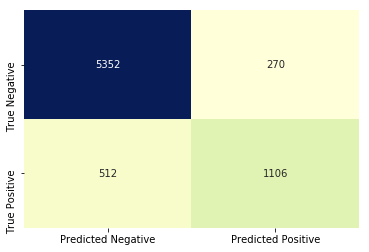

In [107]:
heatmap_1 = pd.DataFrame(confusion_matrix(y_test, y_pred_1))
heatmap_1.columns = ['Predicted Negative','Predicted Positive']
heatmap_1.index = ['True Negative', 'True Positive']
ax = sns.heatmap(heatmap_1, annot=True,fmt="d", cmap="YlGnBu",cbar=False)

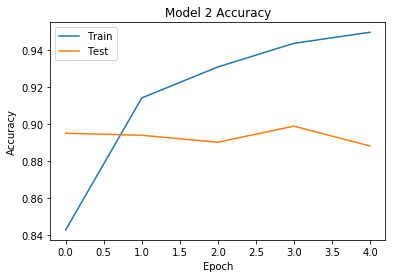

In [128]:
# Accuracy plot
plt.plot(results1.history['acc'])
plt.plot(results1.history['val_acc'])
plt.title('Model 2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

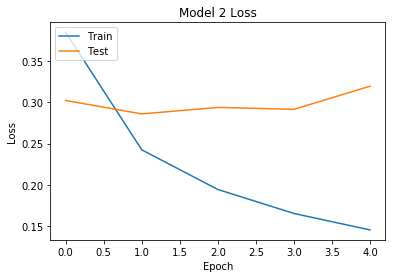

In [126]:
# Loss plot
plt.plot(results1.history['loss'])
plt.plot(results1.history['val_loss'])
plt.title('Model 2 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Model 2 (Functional)

In [36]:
# Create layers for model #2
# Model adapted from https://keras.io/getting-started/functional-api-guide/
main_input = Input(shape=(input_length,), dtype='int32', name='main_input')

x = Embedding(output_dim=embedding_dim, input_dim=max_words, input_length=input_length)(main_input)

lstm_out = LSTM(32)(x)

auxiliary_output = Dense(1, activation='sigmoid', name='aux_output')(lstm_out)
auxiliary_input = Input(shape=(1,), name='aux_input')
                        
x = keras.layers.concatenate([lstm_out, auxiliary_input])
                        
x = Dense(64, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(64, activation='relu')(x)

main_output = Dense(1, activation='sigmoid', name='main_output')(x)
                        
model2 = Model(inputs=[main_input, auxiliary_input], outputs=[main_output, auxiliary_output])
                        
model2.compile(optimizer='rmsprop', loss='binary_crossentropy',loss_weights=[1., 0.2], metrics=['acc'])

model2.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
main_input (InputLayer)         (None, 100)          0                                            
__________________________________________________________________________________________________
embedding_3 (Embedding)         (None, 100, 150)     1500000     main_input[0][0]                 
__________________________________________________________________________________________________
lstm_3 (LSTM)                   (None, 32)           23424       embedding_3[0][0]                
__________________________________________________________________________________________________
aux_input (InputLayer)          (None, 1)            0                                            
__________________________________________________________________________________________________
concatenat

In [37]:
time_train = time_train.reshape(-1,1)

In [38]:
results2 = model2.fit([text_train, time_train], [labels_train, labels_train], epochs=5, batch_size=32,validation_split=0.7)

# Save model
model2.save('my_model_2.h5')

Train on 6516 samples, validate on 15204 samples
Epoch 1/5
6516/6516 [==============================] - 74s 11ms/step - loss: 3.7967 - main_output_loss: 3.7178 - aux_output_loss: 0.3944 - main_output_acc: 0.7693 - aux_output_acc: 0.8467 - val_loss: 3.6918 - val_main_output_loss: 3.6299 - val_aux_output_loss: 0.3095 - val_main_output_acc: 0.7748 - val_aux_output_acc: 0.8825
Epoch 2/5
6516/6516 [==============================] - 72s 11ms/step - loss: 3.7669 - main_output_loss: 3.7178 - aux_output_loss: 0.2451 - main_output_acc: 0.7693 - aux_output_acc: 0.9105 - val_loss: 3.6861 - val_main_output_loss: 3.6299 - val_aux_output_loss: 0.2813 - val_main_output_acc: 0.7748 - val_aux_output_acc: 0.8998
Epoch 3/5
6516/6516 [==============================] - 73s 11ms/step - loss: 3.7575 - main_output_loss: 3.7178 - aux_output_loss: 0.1984 - main_output_acc: 0.7693 - aux_output_acc: 0.9277 - val_loss: 3.6870 - val_main_output_loss: 3.6299 - val_aux_output_loss: 0.2859 - val_main_output_acc: 0.7748

In [39]:
model_score = model2.evaluate([text_test, time_test],[labels_test, labels_test], verbose=0)
print('Test loss:', model_score[0])
print('Test main_output_loss:', model_score[1])
print('Test aux_output_loss:', model_score[2])
print('Test main_output_acc:', model_score[3])
print('Test aux_output_acc:', model_score[4])

Test loss: 3.668457115552702
Test main_output_loss: 3.60208267217183
Test aux_output_loss: 0.331872203386291
Test main_output_acc: 0.7765193370165746
Test aux_output_acc: 0.8755524861878453


In [75]:
y_pred_2 = model2.predict([text_test, time_test])

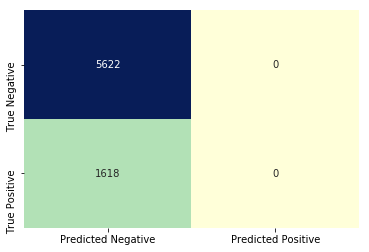

In [111]:
heatmap_1 = pd.DataFrame(confusion_matrix(y_test, y_pred_2[0]))
heatmap_1.columns = ['Predicted Negative','Predicted Positive']
heatmap_1.index = ['True Negative', 'True Positive']
ax = sns.heatmap(heatmap_1, annot=True,fmt="d", cmap="YlGnBu",cbar=False)

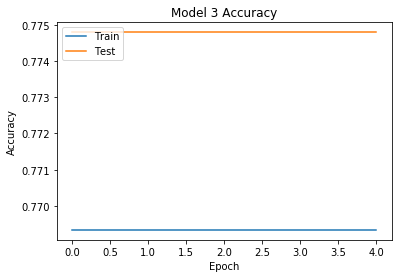

In [129]:
# Accuracy plot
plt.plot(results2.history['main_output_acc'])
plt.plot(results2.history['val_main_output_acc'])
plt.title('Model 3 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

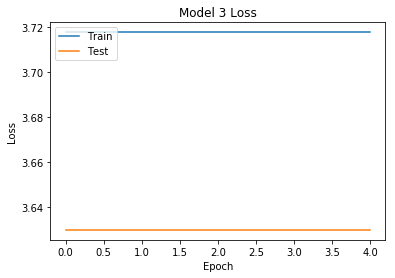

In [127]:
# Loss plot
plt.plot(results2.history['main_output_loss'])
plt.plot(results2.history['val_main_output_loss'])
plt.title('Model 3 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Save/Load

In [276]:
# Save model
model.save('my_model_1.h5')

In [3]:
# Load model
from keras.models import load_model
model = load_model('my_model_0.h5')

### ROC Curve

In [61]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [62]:
#https://hackernoon.com/simple-guide-on-how-to-generate-roc-plot-for-keras-classifier-2ecc6c73115a
y_pred_keras = model.predict(X_test).ravel()
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)
auc_keras = auc(fpr_keras, tpr_keras)

y_pred_keras_1 = model1.predict(X_test).ravel()
fpr_keras_1, tpr_keras_1, thresholds_keras_1 = roc_curve(y_test, y_pred_keras_1)
auc_keras_1 = auc(fpr_keras, tpr_keras)

y_pred_2 = model2.predict([text_test, time_test])
fpr_keras_2, tpr_keras_2, thresholds_keras_2 = roc_curve(labels_test, y_pred_2[0])
auc_keras_2 = auc(fpr_keras_2, tpr_keras_2)

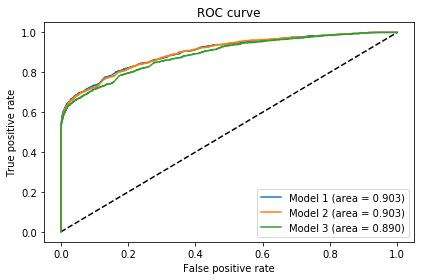

In [83]:
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='Model 1 (area = {:.3f})'.format(auc_keras))
plt.plot(fpr_keras_1, tpr_keras_1, label='Model 2 (area = {:.3f})'.format(auc_keras_1))
plt.plot(fpr_keras_2, tpr_keras_2, label='Model 3 (area = {:.3f})'.format(auc_keras_2))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

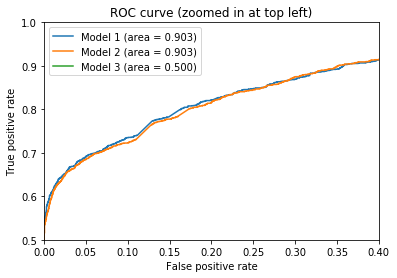

In [81]:
plt.figure(2)
plt.xlim(0, 0.4)
plt.ylim(0.5, 1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='Model 1 (area = {:.3f})'.format(auc_keras))
plt.plot(fpr_keras_1, tpr_keras_1, label='Model 2 (area = {:.3f})'.format(auc_keras_1))
plt.plot(fpr_keras_2, tpr_keras_2, label='Model 3 (area = {:.3f})'.format(auc_keras_2))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve (zoomed in at top left)')
plt.legend(loc='best')
plt.show()